Datos descargados y guardados en archivos CSV.
Archivo: BTCUSDT_1m.csv - Última vela: 67800.02 67800.01
La última vela fue: Bajista
Métricas de evaluación del modelo:
Error Cuadrático Medio (MSE): 86.29884109472114
Error Absoluto Medio (MAE): 5.566105345756878
Coeficiente de Determinación (R^2): 0.9982135422582907
Archivo: BTCUSDT_5m.csv - Última vela: 67800.02 67800.02
La última vela fue: Bajista
Métricas de evaluación del modelo:
Error Cuadrático Medio (MSE): 535.2073418983117
Error Absoluto Medio (MAE): 15.964806069043552
Coeficiente de Determinación (R^2): 0.9969012404382387
Archivo: BTCUSDT_15m.csv - Última vela: 67763.47 67800.02
La última vela fue: Alcista
Métricas de evaluación del modelo:
Error Cuadrático Medio (MSE): 2437.749419999262
Error Absoluto Medio (MAE): 36.41623072217612
Coeficiente de Determinación (R^2): 0.9940371434653997
Archivo: BTCUSDT_1h.csv - Última vela: 67736.95 67800.02
La última vela fue: Alcista
Métricas de evaluación del modelo:
Error Cuadrático Medio (

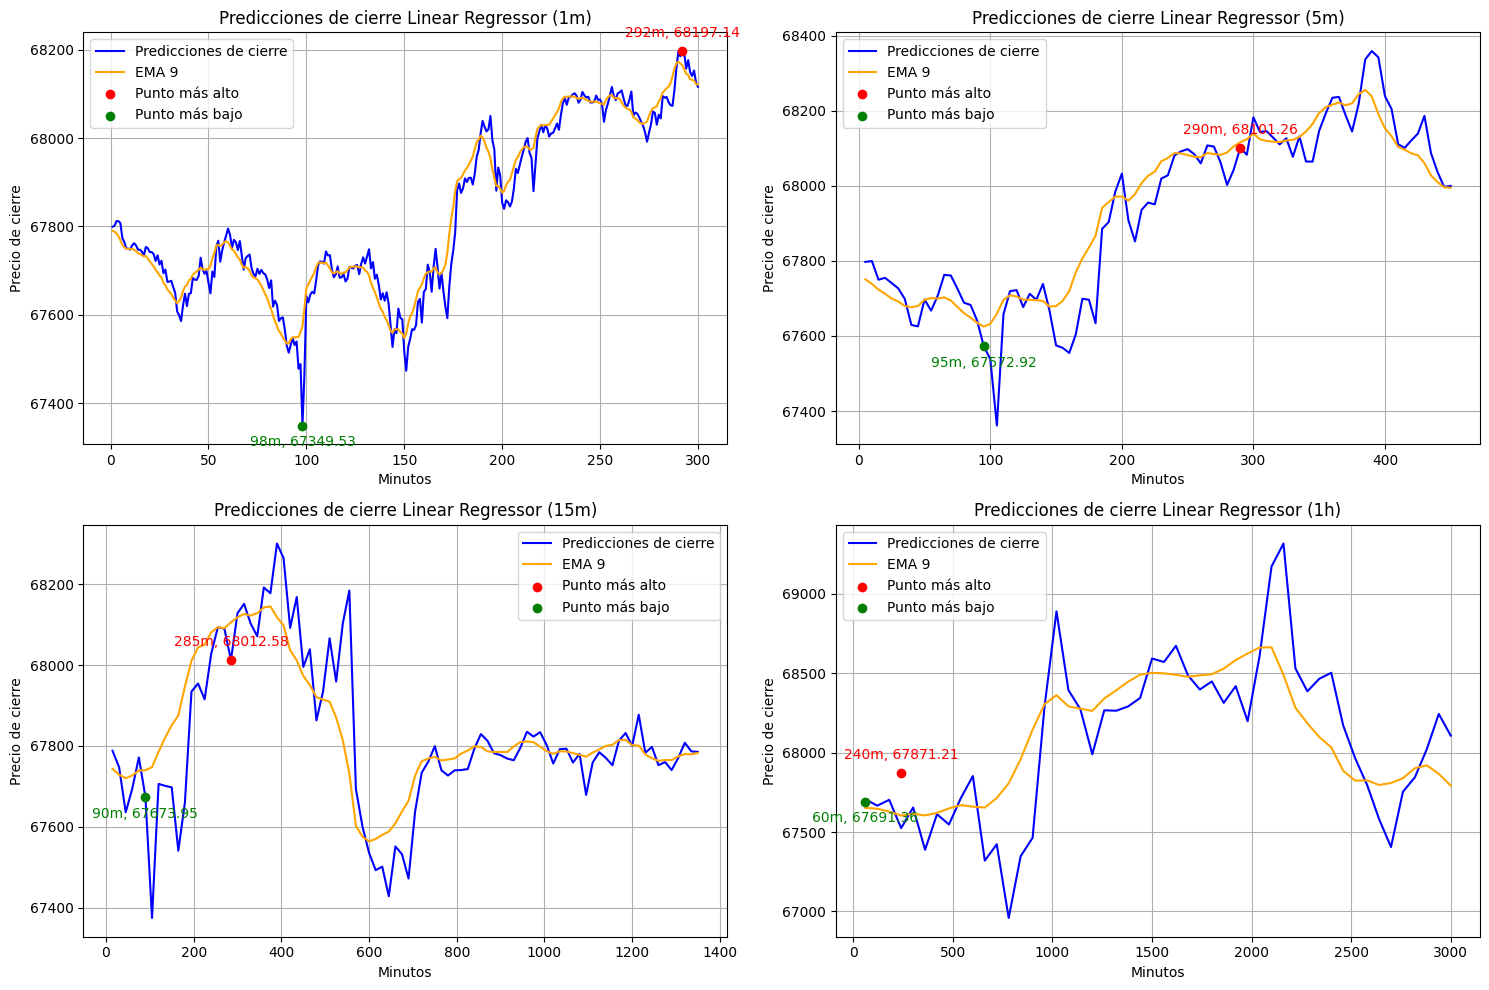

In [1]:
from tvDatafeed import TvDatafeed, Interval
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Conexión con tvDatafeed
tv = TvDatafeed('vaxebef549@artgulin.com', 'vaxebef549@artgulin.com')

# Temporalidades a descargar
intervals = {
    '1m': Interval.in_1_minute,
    '5m': Interval.in_5_minute,
    '15m': Interval.in_15_minute,
    '1h': Interval.in_1_hour
}

# Descargar datos y guardarlos en un diccionario
data = {}
for label, interval in intervals.items():
    df = tv.get_hist(symbol='BTCUSDT', exchange='BINANCE', interval=interval, n_bars=1000)
    df = pd.DataFrame(df)
    df.reset_index(inplace=True)
    df.to_csv(f'BTCUSDT_{label}.csv', index=False)

print("Datos descargados y guardados en archivos CSV.")

# Función para calcular la EMA de 9 periodos
def calculate_ema(data, period=20):
    return data.ewm(span=period, adjust=False).mean()

# Función para procesar datos y entrenar el modelo
def process_and_predict(filename, interval_label, prediction_steps):
    # Cargar los datos
    df = pd.read_csv(filename)
    
    # Guardar los últimos precios de apertura y cierre
    last_close = df.iloc[-1]['close']
    last_open = df.iloc[-1]['open']
    last_date = df['datetime'].iloc[-1]
    print(f'Archivo: {filename} - Última vela:', last_open, last_close)
    
    # Calcular la dirección de la última vela
    last_direction_candle = 'Alcista' if last_close > last_open else 'Bajista'
    print(f'La última vela fue: {last_direction_candle}')
    
    # Calcular la EMA de 9 periodos
    df['ema_9'] = calculate_ema(df['close'], period=9)
    
    # Eliminar columnas innecesarias
    df.drop(['datetime', 'symbol'], axis='columns', inplace=True)
    
    # Separar las características (X) y la variable objetivo (y)
    X = df.drop(['close'], axis='columns')
    y_close = df['close']
    
    # Normalizar los datos
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Dividir los datos en conjuntos de entrenamiento y prueba
    X_train, X_test, y_close_train, y_close_test = train_test_split(X_scaled, y_close, test_size=0.2, random_state=42)
    
    # Entrenar el modelo de regresión lineal
    lin_close = LinearRegression()
    lin_close.fit(X_train, y_close_train)
    
    # Realizar predicciones en el conjunto de prueba
    predictions_lin_close = lin_close.predict(X_test)
    
    # Calcular las métricas de evaluación
    mse = mean_squared_error(y_close_test, predictions_lin_close)
    mae = mean_absolute_error(y_close_test, predictions_lin_close)
    r2 = r2_score(y_close_test, predictions_lin_close)
    
    print('Métricas de evaluación del modelo:')
    print('Error Cuadrático Medio (MSE):', mse)
    print('Error Absoluto Medio (MAE):', mae)
    print('Coeficiente de Determinación (R^2):', r2)
    
    # Preparar los datos para la predicción
    step_size = {'1m': 1, '5m': 5, '15m': 15, '1h': 60}[interval_label]
    real_data = X.tail(prediction_steps).reset_index(drop=True)
    real_data_scaled = scaler.transform(real_data)
    
    # Realizar predicciones para el precio de cierre
    predictions_close = lin_close.predict(real_data_scaled)
    
    # Convertir el generador en listas separadas de pasos y predicciones
    predicciones = list(reversed(predictions_close))
    steps = [(i + 1) * step_size for i in range(len(predicciones))]
    
    # Obtener la EMA para los últimos periodos
    ema_9 = df['ema_9'].tail(prediction_steps).reset_index(drop=True)
    ema_9_pred = ema_9.iloc[::-1].tolist()  # Revertir el orden para que coincida con las predicciones
    
    return steps, predicciones, ema_9_pred

# Crear figura y subplots
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.flatten()

# Procesar y predecir para cada archivo y graficar en subplots
steps_dict = {}
predicciones_dict = {}
ema_dict = {}

for i, label in enumerate(intervals.keys()):
    prediction_steps = 300 if label == '1m' else 90
    steps, predicciones, ema_9_pred = process_and_predict(f'BTCUSDT_{label}.csv', label, prediction_steps)
    steps_dict[label] = steps
    predicciones_dict[label] = predicciones
    ema_dict[label] = ema_9_pred
    
    # Limitar los datos a 3000 minutos para la gráfica de 1 hora
    if label == '1h':
        max_minutes = 3000
        steps = [step for step in steps if step <= max_minutes]
        predicciones = predicciones[-len(steps):]
        ema_9_pred = ema_9_pred[-len(steps):]
    
    axs[i].plot(steps, predicciones, label='Predicciones de cierre', color='blue')
    axs[i].plot(steps, ema_9_pred, label='EMA 9', color='orange')
    axs[i].set_title(f'Predicciones de cierre Linear Regressor ({label})')
    axs[i].set_xlabel('Minutos')
    axs[i].set_ylabel('Precio de cierre')
    axs[i].legend()
    axs[i].grid(True)

# Encontrar el punto más alto y más bajo en la gráfica de 1 minuto
max_index_1m = predicciones_dict['1m'].index(max(predicciones_dict['1m']))
min_index_1m = predicciones_dict['1m'].index(min(predicciones_dict['1m']))
max_step_1m = steps_dict['1m'][max_index_1m]
min_step_1m = steps_dict['1m'][min_index_1m]

# Marcar estos puntos en todas las gráficas
for i, label in enumerate(intervals.keys()):
    interval_step = {'1m': 1, '5m': 5, '15m': 15, '1h': 60}[label]
    max_step = max_step_1m // interval_step * interval_step
    min_step = min_step_1m // interval_step * interval_step
    
    if max_step in steps_dict[label]:
        max_index = steps_dict[label].index(max_step)
        axs[i].scatter(steps_dict[label][max_index], predicciones_dict[label][max_index], color='red', label='Punto más alto', zorder=5)
        axs[i].annotate(f'{max_step}m, {predicciones_dict[label][max_index]:.2f}', 
                        (steps_dict[label][max_index], predicciones_dict[label][max_index]), 
                        textcoords="offset points", xytext=(0,10), ha='center', color='red')
    
    if min_step in steps_dict[label]:
        min_index = steps_dict[label].index(min_step)
        axs[i].scatter(steps_dict[label][min_index], predicciones_dict[label][min_index], color='green', label='Punto más bajo', zorder=5)
        axs[i].annotate(f'{min_step}m, {predicciones_dict[label][min_index]:.2f}', 
                        (steps_dict[label][min_index], predicciones_dict[label][min_index]), 
                        textcoords="offset points", xytext=(0,-15), ha='center', color='green')
    
    axs[i].legend()

# Ajustar el layout para que no haya solapamiento
plt.tight_layout()
plt.show()
